This code demonstrates a complete workflow for building, training, and evaluating a deep learning model to classify the MNIST dataset (a collection of handwritten digit images).

### **Overview**
1. **Dataset**: The MNIST dataset is used, which contains grayscale images of digits (0-9) and their corresponding labels. The data is loaded from a hosted `.npz` file.
2. **Preprocessing**:
   - The images are normalized by dividing pixel values by 255.
   - The labels are one-hot encoded to prepare them for categorical classification.
   - The training data is split into training and validation sets.
3. **Model**:
   - A simple feedforward neural network (fully connected layers) is implemented using TensorFlow's Keras API.
   - Architecture:
     - Input layer with 784 features (flattened 28x28 images).
     - 3 hidden layers with 64, 32, and 16 neurons, each using the ReLU activation function.
     - Output layer with 10 neurons (softmax activation) for predicting digit classes (0-9).
   - Loss function: `categorical_crossentropy` for multi-class classification.
   - Optimizer: Adam with a learning rate of 0.01.
4. **Training**:
   - The model is trained for 30 epochs with a batch size of 32.
   - Training accuracy and loss, along with validation metrics, are monitored during training.
5. **Evaluation**:
   - The model is evaluated on the test dataset.
   - Metrics such as accuracy, recall, precision, and F1-score are calculated.
   - A confusion matrix is plotted to visualize model performance across all classes.
6. **Visualization**:
   - Random samples from the training and test datasets are displayed with their true labels and predicted labels for qualitative evaluation.

### **Purpose**
The code showcases the ability to:
- Train a deep learning model on image data.
- Preprocess data effectively for neural networks.
- Evaluate model performance using key metrics.
- Visualize predictions and dataset distributions.

This implementation solves the problem of digit classification and achieves reasonable accuracy on the MNIST dataset using a straightforward and interpretable neural network model.

# Basic setting

### Measuring execution time

In [71]:
!pip install --q ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 3.32 s (started: 2025-01-22 23:40:01 +00:00)


### Library

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

time: 5.05 ms (started: 2025-01-22 23:39:46 +00:00)


# Data collection

### Load data from url

In [53]:
from io import BytesIO
import requests

data_url = 'https://raw.githubusercontent.com/20161609/data_box/main/mnist.npz'

# Download file from Url and load it to memory.
response = requests.get(data_url)
if response.status_code == 200:
    npz_data = BytesIO(response.content)  # Load it to memory
    df = np.load(npz_data)  # Read file on numpy

    # Check npz file's content
    print("Keys included in npz:", df.files)
    print("x_train shape:", df['x_train'].shape)
    print("y_train shape:", df['y_train'].shape)
else:
    print("Failed to download file:", response.status_code)

Keys included in npz: ['x_test', 'x_train', 'y_train', 'y_test']
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
time: 730 ms (started: 2025-01-22 23:07:20 +00:00)


# Data preparation

### Split: train and test

In [54]:
X_train = df['x_train']
X_test = df['x_test']
y_train = df['y_train']
y_test = df['y_test']

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

time: 378 ms (started: 2025-01-22 23:07:20 +00:00)


### Visualize random samples

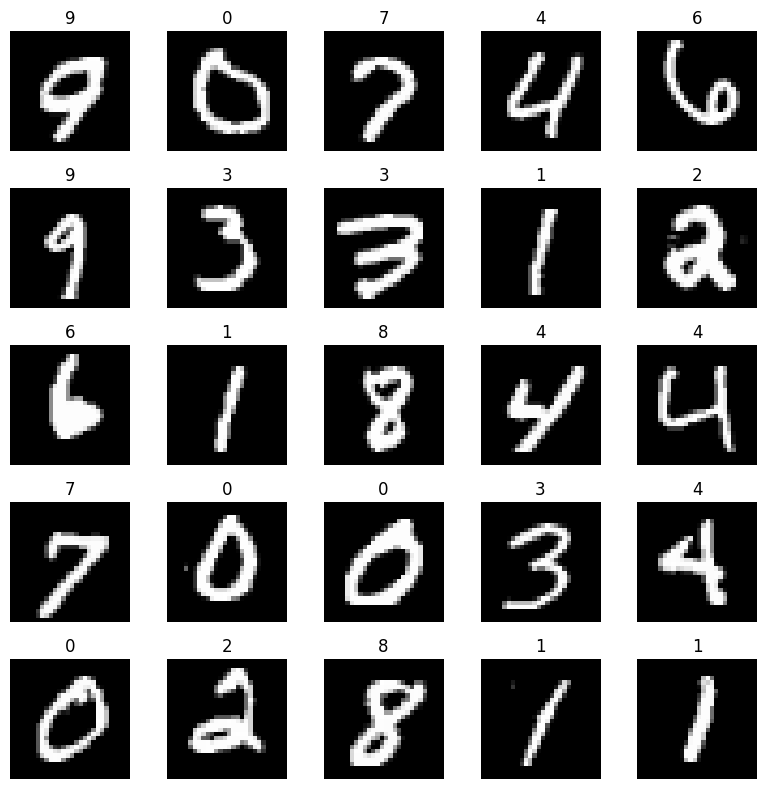

time: 3.29 s (started: 2025-01-22 23:07:27 +00:00)


In [55]:
# np.random.seed(42)
sample = np.random.randint(60000, size=25)
sample

fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(y_train[idx])
fig.tight_layout()
plt.show()

### Count occurrences of each label

In [25]:
sr = pd.Series(y_train).value_counts().sort_index()
sr

,count
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851
9,5949


time: 20.3 ms (started: 2025-01-22 22:02:04 +00:00)


### Plot the distribution of labels

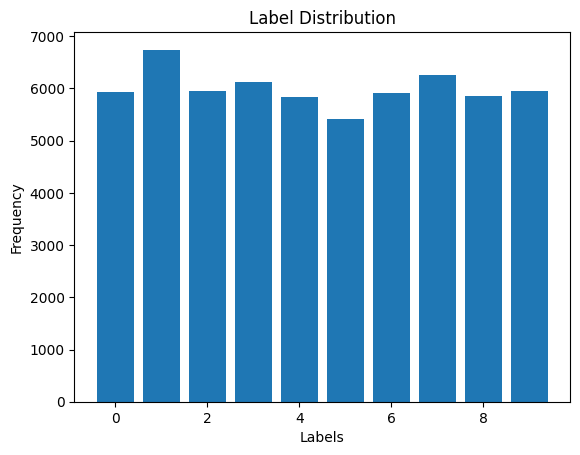

time: 174 ms (started: 2025-01-22 23:10:01 +00:00)


In [56]:
plt.bar(sr.index, sr)
plt.title('Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Frequency')
plt.show()

### Split train and validation

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(48000, 28, 28) (12000, 28, 28)
(48000,) (12000,)
time: 93.7 ms (started: 2025-01-22 23:13:43 +00:00)


In [ ]:
## 3.학습용, 검증용 데이터 분리

# Data proprecessing

### Min-Max Scaling

In [60]:
X_train_s = X_train / 255.
X_val_s = X_val / 255.

time: 404 ms (started: 2025-01-22 23:32:02 +00:00)


### One-hot Encoding

In [59]:
y_train_o = to_categorical(y_train)
y_val_o = to_categorical(y_val)

y_train_o.shape, y_val_o.shape

((48000, 10), (12000, 10))

time: 19.3 ms (started: 2025-01-22 23:31:56 +00:00)


### Flatten images into 1D arrays for fully connected layers

In [64]:
X_train_s = X_train_s.reshape(-1, 28*28)
X_val_s = X_val_s.reshape(-1, 28*28)

X_train_s.shape, X_val_s.shape

((48000, 784), (12000, 784))

time: 7.07 ms (started: 2025-01-22 23:33:12 +00:00)


# Model

### Create model

In [ ]:
# Define a neural network model
model = Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),  # First hidden layer
    layers.Dense(32, activation='relu'),                     # Second hidden layer
    layers.Dense(16, activation='relu'),                     # Third hidden layer
    layers.Dense(10, activation='softmax'),                  # Output layer for 10 classes
])

# Display the model summary
model.summary()

### Compile model

In [ ]:
# Compile the model with Adam optimizer
adam = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(
    loss='categorical_crossentropy',  # Loss function for multi-class classification
    optimizer=adam,
    metrics=['accuracy']             # Metric to monitor during training
)

### History

In [66]:
# Set training parameters
EPOCHS = 30
BATCH_SIZE = 32

# Train the model with training data and validate on validation data
history = model.fit(
    X_train_s, y_train_o,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_s, y_val_o)
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9839 - loss: 0.0699 - val_accuracy: 0.9626 - val_loss: 0.2183
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9854 - loss: 0.0649 - val_accuracy: 0.9678 - val_loss: 0.2103
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9843 - loss: 0.0643 - val_accuracy: 0.9666 - val_loss: 0.2147
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9869 - loss: 0.0566 - val_accuracy: 0.9657 - val_loss: 0.2042
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9850 - loss: 0.0712 - val_accuracy: 0.9630 - val_loss: 0.2495
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9870 - loss: 0.0587 - val_accuracy: 0.9642 - val_loss: 0.2306
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9870 - loss: 0.0574 - val_accuracy: 0.9677 - val_loss: 0.2163
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9869 - loss: 0.0588 -

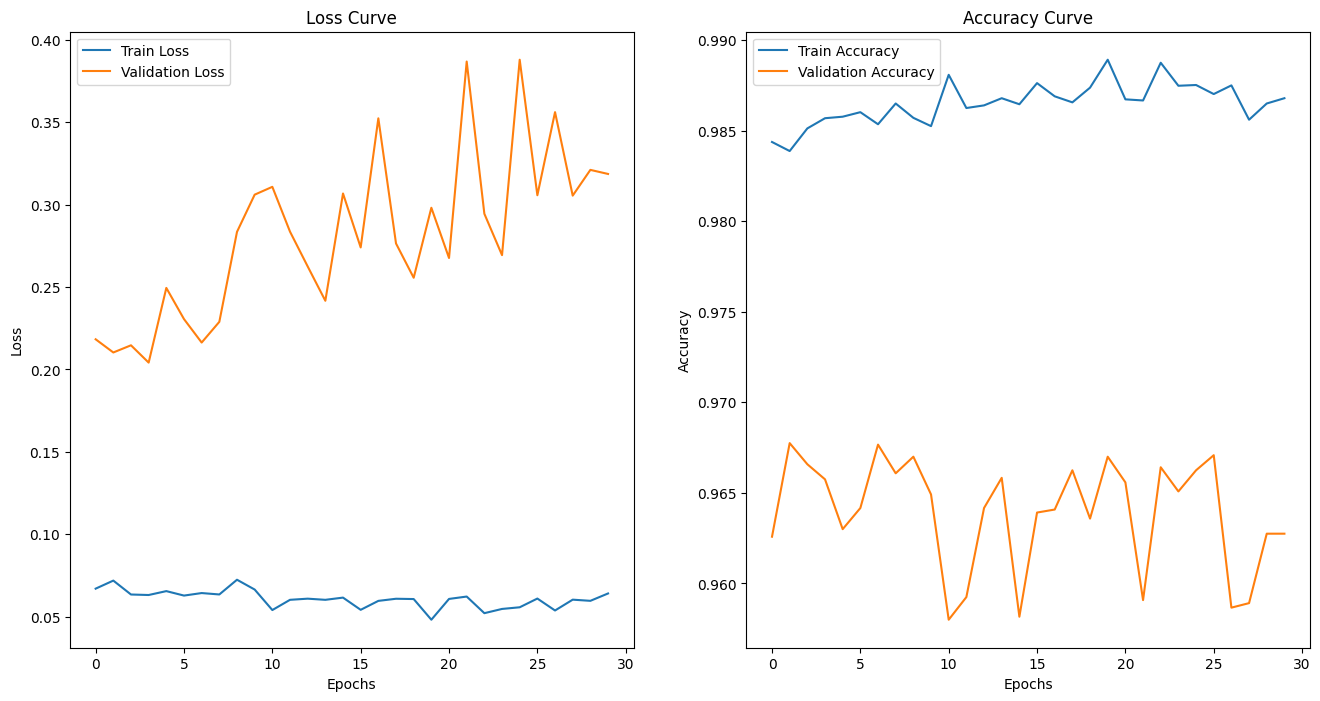

time: 409 ms (started: 2025-01-22 23:38:41 +00:00)


In [67]:
# Function to plot training history
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))

    # Plot loss curve
    plt.subplot(1, 2, 1)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='Validation Loss')
    plt.title('Loss Curve')
    plt.legend()

    # Plot accuracy curve
    plt.subplot(1, 2, 2)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.show()

# Plot training history
plot_history(history)

# Evaluate

### Preprocess test dataset

In [72]:
X_test_s = X_test / 255.
X_test_s = X_test_s.reshape(-1, 28*28)  # Flatten images
y_test_o = to_categorical(y_test)       # One-hot encode test labels

X_test_s.shape, y_test_o.shape

((10000, 784), (10000, 10))

time: 47.4 ms (started: 2025-01-22 23:43:50 +00:00)


### Get prediction

In [73]:
# Make predictions on test data
y_pred = model.predict(X_test_s)

# Convert predictions from probabilities to class labels
y_pred = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
time: 852 ms (started: 2025-01-22 23:43:53 +00:00)


### Evaluate metrics on test data

Accuracy: 0.9637
Recall: 0.9631365074395832
Precision: 0.9642842370215812
F1 Score: 0.9632930017179291


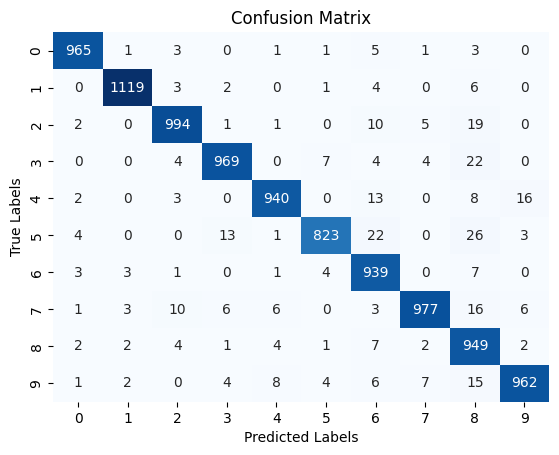

time: 328 ms (started: 2025-01-22 23:43:59 +00:00)


In [74]:
def print_metrics(y_true, y_pred, aver='binary'):
    print('Accuracy:', accuracy_score(y_true, y_pred))
    print('Recall:', recall_score(y_true, y_pred, average=aver))
    print('Precision:', precision_score(y_true, y_pred, average=aver))
    print('F1 Score:', f1_score(y_true, y_pred, average=aver))

    # Plot confusion matrix
    cfm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

print_metrics(y_test, y_pred, aver='macro')

### Visualize predictions on random test samples

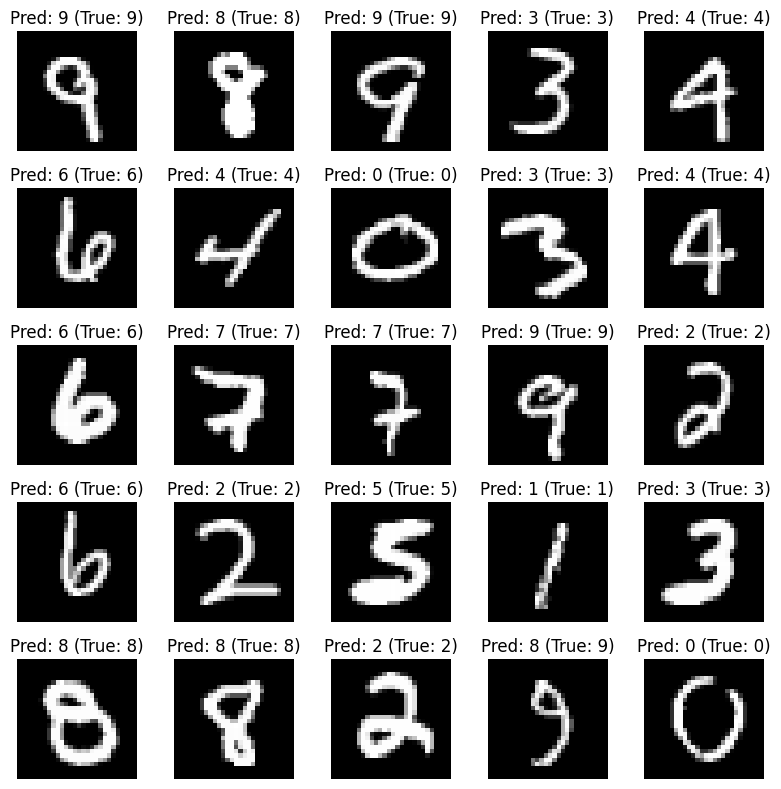

time: 1.48 s (started: 2025-01-22 23:44:15 +00:00)


In [75]:
sample = np.random.randint(10000, size=25)

fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_test[idx], cmap='gray')  # Display grayscale image
    plt.axis('off')
    plt.title(f'Pred: {y_pred[idx]} (True: {y_test[idx]})')  # Show predicted and true labels
fig.tight_layout()
plt.show()